/var/folders/s2/nry612l527j2xxdsq0_70h6m0000gn/T/ipykernel_60865/3473190419.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cdf['Sample_Date'] = pd.to_datetime(cdf['Sample_Date'])
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [S]


/Users/elizabethmurphy/miniconda3/envs/SRTI/lib/python3.13/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
There were 14 divergences after tuning. Increase `target_accept` or reparameterize.


Text(0.5, 0, 'Days before detection')

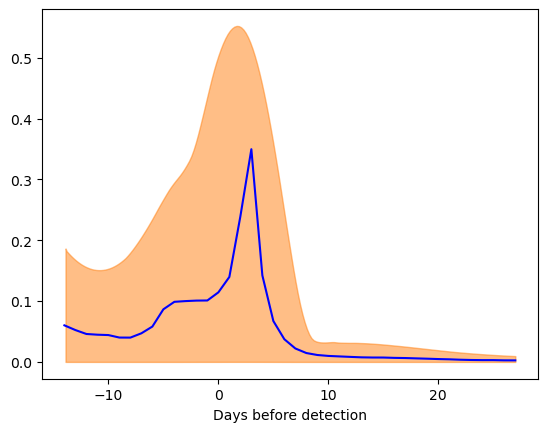

In [ ]:
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd 
import pickle
import json
# import requests
from scipy import signal
from datetime import date,timedelta
# import yaml
import copy

import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

start = pd.to_datetime('2023-01-01')
eval_dates = [start + datetime.timedelta(days=7*j) for j in range(0,52)]


# option 2: use SD county data, resolved by catchment. 
cases = pd.read_csv('/Users/elizabethmurphy/Downloads/cases.csv',index_col=0)
cases = cases[cases['catchment'] =='PointLoma']
cases = cases[(cases.index>='2021-04-01') & (cases.index<='2022-07-01')]
cases.index = pd.to_datetime(cases.index)
cases = cases.groupby(pd.Grouper(freq='D'))[['new_cases']].sum()
cases['cases'] = cases['new_cases'].rolling(window=7, center=True, min_periods=0).mean()
ww_dict = {'Point Loma':['/Users/elizabethmurphy/Downloads/PointLoma_sewage_seqs.csv','/Users/elizabethmurphy/Downloads/PointLoma_sewage_qPCR.csv']}
for site, files in zip(ww_dict.keys(),ww_dict.values()):
    df = pd.read_csv(f'{files[0]}')

    df['Date'] = pd.to_datetime(df['Date'])
    df.columns = [dfc.split(' (')[0] for dfc in df.columns]
    df =df.set_index('Date')
    df = df[df.index>='2021-04-01']
    df = df[df.index<='2022-07-01']
    df = df.dropna(axis = 0, how = 'all')
    df = df.fillna(0)
    df = df/100.

    df = df.drop(columns=['Other'])
    df = df[df.columns[df.sum(axis=0) > 0.01]]

    cdf = pd.read_csv(f'{files[1]}')
    cdf['Sample_Date'] = pd.to_datetime(cdf['Sample_Date'])
    cdf =cdf.set_index('Sample_Date')

    cdf = cdf.resample('D').asfreq()
    cdf = cdf.rolling(window=7, center=True, min_periods=0).mean()
    sharedInds = np.sort(list(set(cdf.index) & set(cases.index)))
    cdf = cdf.loc[sharedInds]



minInd = np.max([cdf.index.min(),cases.index.min()])
maxInd = np.min([cdf.index.max(),cases.index.max()])

cdf = cdf[cdf.index>=minInd]
cdf = cdf[cdf.index<=maxInd]

cases = cases[cases.index>=minInd]
cases = cases[cases.index<=maxInd]

cdf = pd.concat([cdf,cases],axis=1)
cdf = cdf.dropna(how='any')

N = 42
F = 14
X = np.array([cdf['cases'].values[(j-F):(j+N-F)] for j in range(F,(cdf.shape[0]-N+F))])#/cdf['cases'].mean()
Y = np.array(cdf['Mean viral gene copies/L'].values[F:(len(cdf['Mean viral gene copies/L'])-N+F)])/cdf['Mean viral gene copies/L'].mean()


with pm.Model() as shedding_model:
    S = pm.HalfFlat("S",shape=N)
    mu = pm.math.dot(X, S)
    Y_obs = pm.Gamma("Y_obs", alpha = mu/50, beta=50, observed=Y)
    trace = pm.sample(1000, return_inferencedata=True)


lags = np.arange(N) - F
fig,ax = plt.subplots()
az.plot_hdi(lags, trace.posterior["S"].values, hdi_prob=0.95,ax=ax)
ax.plot(lags, np.median(trace.posterior["S"].values,axis=(0,1)), color="blue")
ax.set_xlabel("Days before detection")

(CVXPY) Jul 25 03:32:13 PM: Your problem has 42 variables, 156 constraints, and 0 parameters.
(CVXPY) Jul 25 03:32:13 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 25 03:32:13 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 25 03:32:13 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 25 03:32:13 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jul 25 03:32:13 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) Jul 25 03:32:13 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Jul 25 03:32:13 PM: Applying reduction Dcp2Cone
(CVXPY) Jul 25 03:32:13 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jul 25 03:32:13 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Jul 25 03:32:13 PM: Applying reduction CLARABEL
(CVXPY) Jul 25 03:32:13 PM: Finished problem compila

                                     CVXPY                                     
                                     v1.6.6                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 124
  constraints

(CVXPY) Jul 25 03:32:13 PM: Problem status: optimal
(CVXPY) Jul 25 03:32:13 PM: Optimal value: 3.806e+07
(CVXPY) Jul 25 03:32:13 PM: Compilation took 1.284e-02 seconds
(CVXPY) Jul 25 03:32:13 PM: Solver (including time spent in interface) took 2.598e-02 seconds


  0  +0.0000e+00  -4.3000e+04  4.30e+04  6.61e-01  6.42e-02  1.00e+00  6.26e+06   ------   
  1  +3.1336e+07  +3.1837e+07  1.60e-02  1.12e-01  2.70e-06  5.08e+05  8.78e+05  9.37e-01  
  2  +3.5549e+07  +3.5700e+07  4.24e-03  2.25e-02  4.88e-07  1.52e+05  1.60e+05  8.33e-01  
  3  +3.6718e+07  +3.6791e+07  2.00e-03  9.80e-03  2.08e-07  7.40e+04  5.94e+04  6.92e-01  
  4  +3.7343e+07  +3.7354e+07  3.09e-04  1.96e-03  4.12e-08  1.16e+04  1.98e+04  7.71e-01  
  5  +3.7503e+07  +3.7520e+07  4.64e-04  1.72e-03  3.61e-08  1.75e+04  9.35e+03  7.23e-01  
  6  +3.7697e+07  +3.7703e+07  1.71e-04  7.16e-04  1.50e-08  6.48e+03  4.79e+03  7.62e-01  
  7  +3.7703e+07  +3.7713e+07  2.45e-04  7.72e-04  1.62e-08  9.29e+03  3.47e+03  5.53e-01  
  8  +3.7855e+07  +3.7857e+07  4.82e-05  2.06e-04  4.32e-09  1.84e+03  1.39e+03  8.52e-01  
  9  +3.7892e+07  +3.7894e+07  4.50e-05  1.72e-04  3.59e-09  1.71e+03  9.78e+02  5.08e-01  
 10  +3.7949e+07  +3.7950e+07  1.67e-05  6.59e-05  1.38e-09  6.38e+02  4.91e+02 

Text(0.5, 0, 'Days after detection')

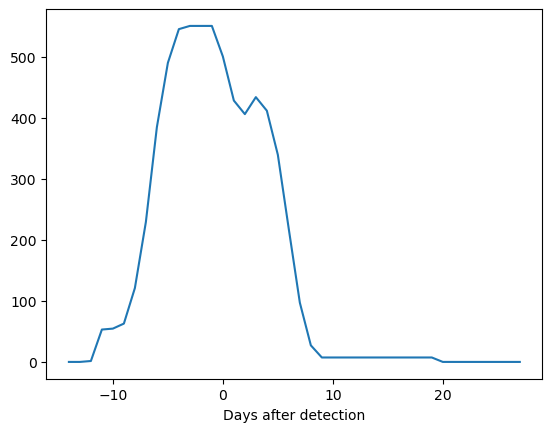

In [24]:
# frequentist approach
N = 42
F = 14
# first, let's learn the shedding kernel
X = np.array([cdf['cases'].values[(j-F):(j+N-F)] for j in range(F,(cdf.shape[0]-N+F))])#/cdf['Mean viral gene copies/L'].mean()
Y = np.array(cdf['Mean viral gene copies/L'].values[F:(len(cdf['Mean viral gene copies/L'])-N+F)])#/cdf['Mean viral gene copies/L'].mean()

import cvxpy as cp
# least squares problem
x = cp.Variable(N)
cost = cp.norm(X @ x - Y,2)
## add some constraints on the shape of the curve. 
constraints = [x >= 0, x[0]==0,cp.diff(x[0:F])>=0., cp.abs(cp.diff(x)) <= 1000,cp.abs(cp.diff(x,2)) <= 50,cp.diff(x[N-20:N])<=0.]
prob = cp.Problem(cp.Minimize(cost),constraints)
prob.solve(verbose=True,solver=cp.CLARABEL)
lags = np.arange(N) - F
fig,ax = plt.subplots()
ax.plot(lags,x.value)
ax.set_xlabel("Days after detection")

Text(0, 0.5, 'Cases')

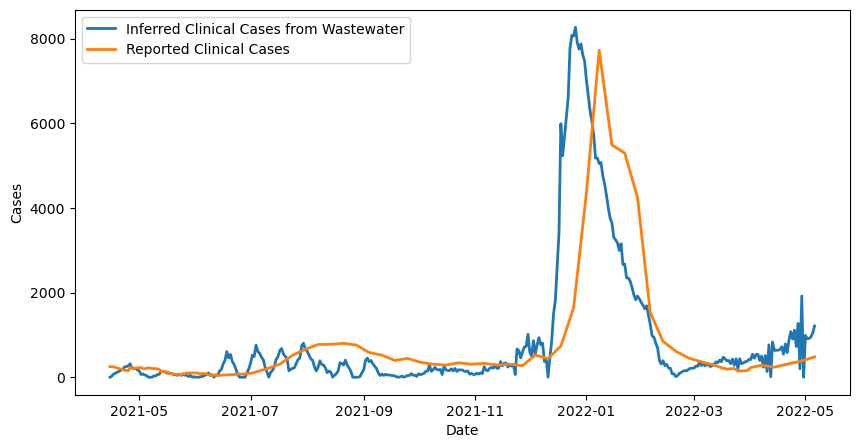

In [ ]:
from numpy.fft import fft, ifft

S = np.median(trace.posterior["S"].values, axis=(0, 1))
S = S / S.sum()

VL = cdf['Mean viral gene copies/L'].rolling(window=7, center=True, min_periods=0).mean()
VL = VL[F:(len(VL)-N+F)]
VL = VL / np.mean(VL) * np.mean(Y)

def inverse(VL, S):
    length = len(VL) - len(S)
    S_pad = np.pad(S, (0, length), mode='constant')
    VL_fft = fft(VL)
    S_fft = fft(S_pad)
    H = S_fft
    H_T = np.conj(H)
    y = VL_fft
    C = (H_T * y) / (H_T * H)

    C = np.real(ifft(C))
    C[C < 0] = 0
    return C

C = inverse(VL, S)

# A^tx=b
# A^-1 A^T x = A^-1 b  ->  x - A^-1 b
#psuedoinverse(S)
#np.linalg
# S^-1 = H^t / H^T H is the psuedo inverse

reported = cdf['cases'].values[F:(len(cdf['cases'])-N+F)]
C_rescaled = C * (np.mean(reported) / np.mean(C))
C_rescaled = C_rescaled[:-28]

C_dates = cdf.index[F:(len(cdf.index)-N+F)]
C_dates_inv = C_dates[:len(C_rescaled)]

plt.figure(figsize=(10, 5))
plt.plot(C_dates_inv, C_rescaled, label='Inferred Clinical Cases from Wastewater', linewidth=2)
plt.plot(C_dates_inv, reported[:len(C_rescaled)], label='Reported Clinical Cases', linewidth=2)
plt.legend()
plt.xlabel('Date')
plt.ylabel('Cases')

In [23]:
cdf['Mean viral gene copies/L'].rolling(window=7, center=True, min_periods=0).mean()

2021-04-01    3.402558e+05
2021-04-02    3.385629e+05
2021-04-03    3.374342e+05
2021-04-04    3.366280e+05
2021-04-05    3.170794e+05
                  ...     
2022-06-27    6.071394e+06
2022-06-28    6.144107e+06
2022-06-29    6.159501e+06
2022-06-30    6.177415e+06
2022-07-01    6.204286e+06
Name: Mean viral gene copies/L, Length: 453, dtype: float64

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import gamma, poisson

import epyestim
import epyestim.covid19 as covid19

ch_cases = pd.Series(C[:-28], index=C_dates_inv).round().astype(int)

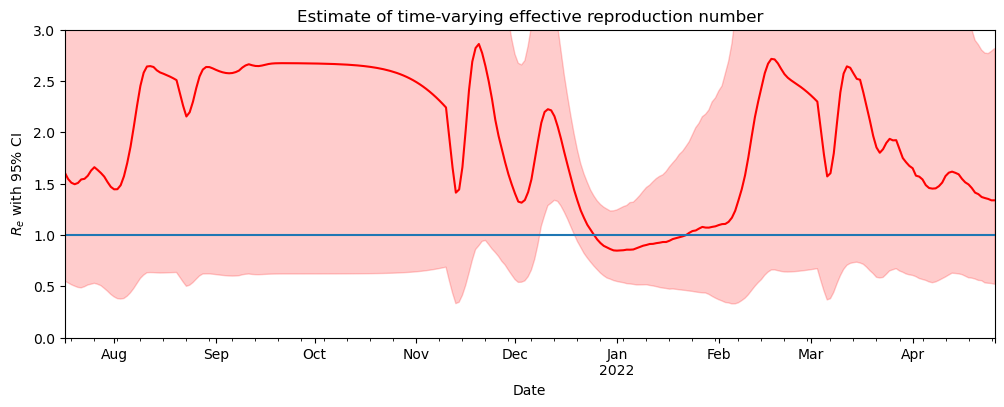

,cases,R_mean,R_var,Q0.025,Q0.5,Q0.975
2022-04-22,1.0,1.446662,0.339899,0.553608,1.368714,2.799685
2022-04-23,1.0,1.434395,0.334014,0.532361,1.358420,2.770469
2022-04-24,1.0,1.433343,0.340639,0.528485,1.349747,2.765706
2022-04-25,1.0,1.417840,0.346932,0.526141,1.336022,2.788781
2022-04-26,1.0,1.422844,0.355933,0.518153,1.336618,2.815098


In [7]:
ch_time_varying_r = covid19.r_covid(ch_cases)

ch_time_varying_r.tail()

fig, ax = plt.subplots(1,1, figsize=(12, 4))

ch_time_varying_r.loc[:,'Q0.5'].plot(ax=ax, color='red')
ax.fill_between(ch_time_varying_r.index, 
                    ch_time_varying_r['Q0.025'], 
                    ch_time_varying_r['Q0.975'], 
                    color='red', alpha=0.2)
ax.set_xlabel('Date')
ax.set_ylabel('$R_e$ with 95% CI')
ax.set_ylim([0,3])
ax.axhline(y=1)
ax.set_title('Estimate of time-varying effective reproduction number')
plt.show()

ch_time_varying_r.tail()

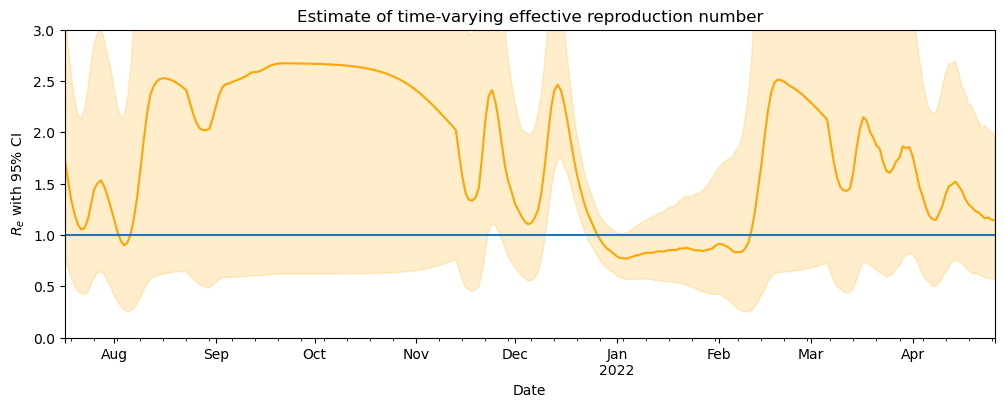

,cases,R_mean,R_var,Q0.025,Q0.5,Q0.975
2022-06-17,892.0,1.024673,0.000406,0.985618,1.024541,1.064582
2022-06-18,1024.0,1.001058,0.000392,0.962688,1.000929,1.040057
2022-06-19,1007.0,0.972938,0.000378,0.934950,0.972806,1.011766
2022-06-20,990.0,0.943841,0.000365,0.906616,0.943712,0.981673
2022-06-21,973.0,0.917656,0.000358,0.881068,0.917527,0.954977


In [14]:
ch_time_varying_r_ = covid19.r_covid(ch_cases, smoothing_window=14, r_window_size=7)

fig, ax = plt.subplots(1,1, figsize=(12, 4))

ch_time_varying_r_.loc[:,'Q0.5'].plot(ax=ax, color='orange')
ax.fill_between(ch_time_varying_r_.index, 
                    ch_time_varying_r_['Q0.025'], 
                    ch_time_varying_r_['Q0.975'], 
                    color='orange', alpha=0.2)
ax.set_xlabel('Date')
ax.set_ylabel('$R_e$ with 95% CI')
ax.set_ylim([0,3])
ax.axhline(y=1)
ax.set_title('Estimate of time-varying effective reproduction number')
plt.show()

ch_time_varying_r.tail()

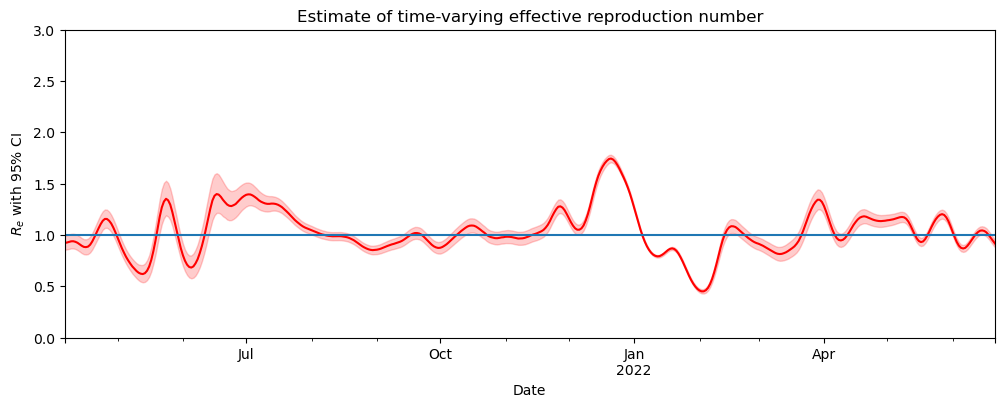

,cases,R_mean,R_var,Q0.025,Q0.5,Q0.975
2022-06-17,892.0,1.024673,0.000406,0.985618,1.024541,1.064582
2022-06-18,1024.0,1.001058,0.000392,0.962688,1.000929,1.040057
2022-06-19,1007.0,0.972938,0.000378,0.934950,0.972806,1.011766
2022-06-20,990.0,0.943841,0.000365,0.906616,0.943712,0.981673
2022-06-21,973.0,0.917656,0.000358,0.881068,0.917527,0.954977


In [9]:
# TEST ON CLINICAL DATA
reported_cases = pd.Series(cases['cases'].values, index=cases.index).round().astype(int)

ch_time_varying_r = covid19.r_covid(reported_cases)

fig, ax = plt.subplots(1,1, figsize=(12, 4))

ch_time_varying_r.loc[:,'Q0.5'].plot(ax=ax, color='red')
ax.fill_between(ch_time_varying_r.index, 
                    ch_time_varying_r['Q0.025'], 
                    ch_time_varying_r['Q0.975'], 
                    color='red', alpha=0.2)
ax.set_xlabel('Date')
ax.set_ylabel('$R_e$ with 95% CI')
ax.set_ylim([0,3])
ax.axhline(y=1)
ax.set_title('Estimate of time-varying effective reproduction number')
plt.show()

ch_time_varying_r.tail()

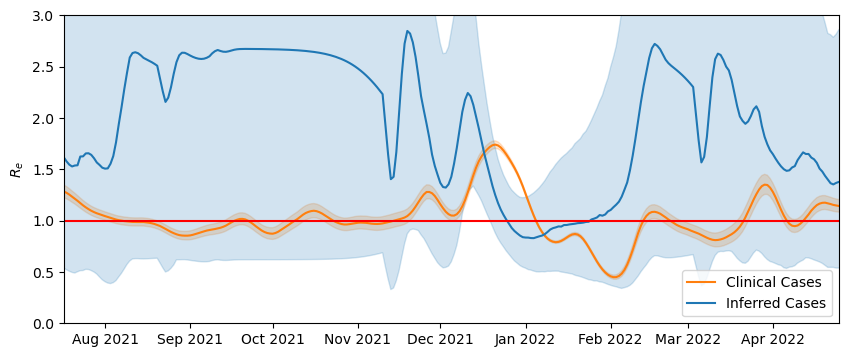

In [10]:
min_len = min(len(C), len(C_dates_inv))

ch_cases = pd.Series(C[:min_len], index=C_dates_inv[:min_len]).round().astype(int)
reported_cases = pd.Series(cases['cases'].values, index=cases.index).round().astype(int)

inferred = covid19.r_covid(ch_cases)
reported = covid19.r_covid(reported_cases)

import matplotlib.ticker as mticker
import matplotlib.dates as mdates


xmin = pd.to_datetime("2021-07-17")
xmax = pd.to_datetime("2022-04-25")


# PLOT FOR POSTER
fig, ax = plt.subplots(1,1, figsize=(10, 4))
reported.loc[:,'Q0.5'].plot(ax=ax, color='#ff7f0e', label='Clinical Cases')
ax.fill_between(reported.index, 
                    reported['Q0.025'], 
                    reported['Q0.975'], 
                    color='#ff7f0e', alpha=0.2)
inferred.loc[:,'Q0.5'].plot(ax=ax, color='#1f77b4', label='Inferred Cases')
ax.fill_between(inferred.index, 
                    inferred['Q0.025'], 
                    inferred['Q0.975'], 
                    color='#1f77b4', alpha=0.2)
ax.set_ylim([0, 3])
ax.axhline(y=1, color='red')
ax.set_xlim(xmin, xmax)
ax.set_ylabel('$R_e$')
plt.legend(loc='lower right')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.show()

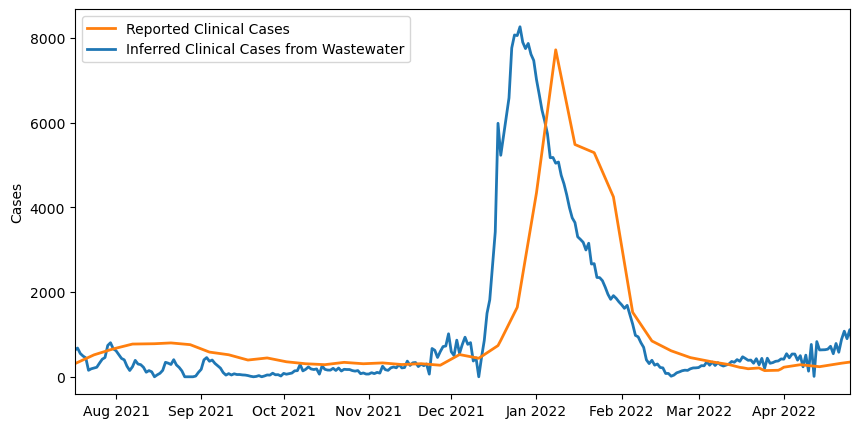

In [16]:
# PLOT FOR POSTER

C = inverse(VL, S)

reported = cdf['cases'].values[F:(len(cdf['cases'])-N+F)]
C_rescaled = C * (np.mean(reported) / np.mean(C))
C_rescaled = C_rescaled[:-28]

C_dates = cdf.index[F:(len(cdf.index)-N+F)]
C_dates_inv = C_dates[:len(C_rescaled)]

VL_raw = cdf['Mean viral gene copies/L'].values[F:(len(cdf['Mean viral gene copies/L'])-N+F)]
VL_raw_scaled = VL_raw / np.mean(VL_raw) * np.mean(reported)
VL_dates = cdf.index[F:(len(cdf.index)-N+F)]

fig, ax = plt.subplots(figsize=(10, 5))
line1, = plt.plot(C_dates_inv, C_rescaled, label='Inferred Clinical Cases from Wastewater', linewidth=2, color='#1f77b4')
line2, = plt.plot(C_dates_inv, reported[:len(C_rescaled)], label='Reported Clinical Cases', linewidth=2, color='#ff7f0e')
plt.legend([line2, line1], ['Reported Clinical Cases', 'Inferred Clinical Cases from Wastewater'])
plt.ylabel('Cases')
ax.set_xlim(xmin, xmax)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.show()

In [ ]:
import pandas as pd 
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.dates as mdates
import matplotlib.pyplot as plt 
import datetime as dt


matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42




def non_uniform_savgol(x, y, window, polynom):
    """
    Applies a Savitzky-Golay filter to y with non-uniform spacing
    as defined in x

    ----------
    x : array_like
        List of floats representing the x values of the data (MUST BE ORDERED)
    y : array_like
        List of floats representing the y values. Must have same length
        as x
    window : int (odd)
        Window length of datapoints. Must be odd and smaller than x
    polynom : int
        The order of polynom used. Must be smaller than the window size

    Returns
    -------
    np.array of float
        The smoothed y values
    """
    if len(x) != len(y):
        raise ValueError('"x" and "y" must be of the same size')

    if len(x) < window:
        raise ValueError('The data size must be larger than the window size')

    if type(window) is not int:
        raise TypeError('"window" must be an integer')

    if window % 2 == 0:
        raise ValueError('The "window" must be an odd integer')

    if type(polynom) is not int:
        raise TypeError('"polynom" must be an integer')

    if polynom >= window:
        raise ValueError('"polynom" must be less than "window"')

    half_window = window // 2
    polynom += 1

    # Initialize variables
    A = np.empty((window, polynom))     # Matrix
    tA = np.empty((polynom, window))    # Transposed matrix
    t = np.empty(window)                # Local x variables
    y_smoothed = np.full(len(y), np.nan)

    # Start smoothing
    for i in range(half_window, len(x) - half_window, 1):
        # Center a window of x values on x[i]
        for j in range(0, window, 1):
            t[j] = x[i + j - half_window] - x[i]

        # Create the initial matrix A and its transposed form tA
        for j in range(0, window, 1):
            r = 1.0
            for k in range(0, polynom, 1):
                A[j, k] = r
                tA[k, j] = r
                r *= t[j]

        # Multiply the two matrices
        tAA = np.matmul(tA, A)

        # Invert the product of the matrices
        tAA = np.linalg.inv(tAA)

        # Calculate the pseudoinverse of the design matrix
        coeffs = np.matmul(tAA, tA)

        # Calculate c0 which is also the y value for y[i]
        y_smoothed[i] = 0
        for j in range(0, window, 1):
            y_smoothed[i] += coeffs[0, j] * y[i + j - half_window]

        # If at the end or beginning, store all coefficients for the polynom
        if i == half_window:
            first_coeffs = np.zeros(polynom)
            for j in range(0, window, 1):
                for k in range(polynom):
                    first_coeffs[k] += coeffs[k, j] * y[j]
        elif i == len(x) - half_window - 1:
            last_coeffs = np.zeros(polynom)
            for j in range(0, window, 1):
                for k in range(polynom):
                    last_coeffs[k] += coeffs[k, j] * y[len(y) - window + j]

    # Interpolate the result at the left border
    for i in range(0, half_window, 1):
        y_smoothed[i] = 0
        x_i = 1
        for j in range(0, polynom, 1):
            y_smoothed[i] += first_coeffs[j] * x_i
            x_i *= x[i] - x[half_window]

    # Interpolate the result at the right border
    for i in range(len(x) - half_window, len(x), 1):
        y_smoothed[i] = 0
        x_i = 1
        for j in range(0, polynom, 1):
            y_smoothed[i] += last_coeffs[j] * x_i
            x_i *= x[i] - x[-half_window - 1]

    return y_smoothed




cdf = pd.read_csv('/Users/elizabethmurphy/Downloads/PointLoma_sewage_qPCR.csv')
cdf['Sample_Date'] = pd.to_datetime(cdf['Sample_Date'])
cdf =cdf.set_index('Sample_Date')
import numpy as np
sharedInds = np.sort(list(set(cdf.index) & set(df.index)))
cdf = cdf.loc[sharedInds]
df = df.loc[sharedInds]

scaleddf = df.mul(cdf['Mean viral gene copies/L'],axis=0)


## interpolate qPCR data


numberDates = [dvi.value/10**11 for dvi in df.index]

cdf['Mean viral gene copies/L'] = non_uniform_savgol(numberDates,cdf['Mean viral gene copies/L'],3,1)
# convert to daily via interpolation
date_ind = pd.date_range(df.index.min(),df.index.max(),freq='D')
cdf = cdf.reindex(date_ind)
cdf = cdf.interpolate()

fig,ax = plt.subplots()
ax.plot(cdf.index,cdf['Mean viral gene copies/L'])
ax.set_yscale('log')

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.set_xlim([df.index.min(),df.index.max()])
plt.setp(ax.get_xticklabels(), rotation=90)
ax.set_ylabel('Mean viral gene copies/L')
fig.tight_layout()
plt.savefig('smoothed_viral_loads.pdf')

#### now, solve the deconvolution problem to get a proxy for cases per day

# alpha = 0.3
# beta = alpha/0.624

# A = 1
# C0 = A*alpha/(beta-alpha)
t = np.linspace(0,40,41)
# c = C0*np.exp(-alpha*t)*(1-np.exp(-(beta-alpha)*t))
# ### estimate growth rates
# ## shedding kernel
def eclipse_model(y, t, b, k, delta, p, mu, c):
    T, I1, I2, Vi, Vni = y
    dydt = [-b*Vi*T, b*Vi*T - k*I1, k*I1- delta*I2, p*mu*I2 - c*Vi, p*(1.-mu)*I2 - c*Vni]
    return dydt

b = 5e-5#1.5e-5
c =10
k= 6#4
mu = 1.0e-4
p = 1e5#1.1e6
delta = 0.5#0.33
from scipy.integrate import odeint
y0 = [1.33e5, 0, 1./30, 0, 0]

sol = odeint(eclipse_model, y0, t, args=(b, k, delta, p, mu, c))

c = sol[:,3:].sum(axis=1)
#simulate simple 
fig,ax = plt.subplots()
ax.plot(np.arange(0,len(t),1),c)
ax.set_yscale('log')
# ax.set_ylim([0,1000])
fig.tight_layout()
plt.savefig('shedding_curve_log.pdf')
plt.close('all')

c = c/c.sum()
#simulate simple 
fig,ax = plt.subplots()
ax.plot(np.arange(0,len(t),1),c)
ax.set_xlabel('Days since infection')
ax.set_ylabel('Shedding Load Density')
# ax.set_yscale('log')
# ax.set_ylim([0,1000])
fig.tight_layout()
plt.savefig('shedding_curve_normalized.pdf')
plt.close('all')

c = c[1:] #drops first day, concentration=0
cFlipped = c[::-1]

# from scipy.signal import deconvolve
# recovered, remainder = deconvolve(cdf['Mean viral gene copies/L'], c)
# ### now convert ww trajectory into infections

tiledMat = np.zeros((len(cdf),len(cdf)))
for j in range(len(cdf)):
    tiledMat[j,np.max([j-len(c)+1,0]):j+1] = cFlipped[np.max([len(c)-j-1,0]):len(c)]


infects = np.dot(np.linalg.pinv(tiledMat),cdf)

fig,ax = plt.subplots()
ax.plot(cdf.index[5:len(infects)-5],infects[5:len(infects)-5])
# ax.set_yscale('log')
# ax.set_ylim([0,1000])
fig.tight_layout()
plt.savefig('infections_curve.pdf')
plt.close('all')

# S^-1 VL = C

# infects = infects[5:len(infects)-5]
import epyestim
import epyestim.covid19 as covid19


infects0 = pd.Series(infects[5:len(infects)-5,0],index=cdf.index[5:len(infects)-5])
ch_time_varying_r = covid19.r_covid(infects0)



def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

fig, ax = plt.subplots(1,1, figsize=(12, 4))
fig.subplots_adjust(left=0.5)

ax0 = ax.twinx()
par2 = ax.twinx()
p2, = par2.plot(cdf.index[5:len(infects)-5],cdf['Mean viral gene copies/L'][5:len(infects)-5],color='black')
p, = ax.plot(cdf.index[5:len(infects)-5],infects[5:len(infects)-5,0],color='grey')

par2.spines["left"].set_position(("axes", -0.15))
make_patch_spines_invisible(par2)
par2.spines["left"].set_visible(True)
par2.yaxis.set_label_position('left')
par2.yaxis.set_ticks_position('left')
p0, = ax0.plot(ch_time_varying_r.index,ch_time_varying_r.loc[:,'Q0.5'],color='red')

# ax.fill_between(ch_time_varying_r.index, 
#                     ch_time_varying_r['Q0.025'], 
#                     ch_time_varying_r['Q0.975'], 
                    # color='red', alpha=0.2)

ax.set_xlabel('date')

ax0.set_ylabel('R(t)')
par2.set_ylabel('Mean viral gene copies/L')
ax.set_ylabel('Number of infections (a.u.)')
# ax.set_ylim([0,3])
ax0.axhline(y=1,color='darksalmon',linestyle='--',alpha=0.6)
ax.set_title('Estimate of time-varying effective reproduction number for Point Loma')

ax.yaxis.label.set_color(p.get_color())
ax0.yaxis.label.set_color(p0.get_color())
par2.yaxis.label.set_color(p2.get_color())

ax.tick_params(axis='y', colors=p.get_color())
ax0.tick_params(axis='y', colors=p0.get_color())
par2.tick_params(axis='y', colors=p2.get_color())

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
# ax.set_xlim([df.index.min(),df.index.max()])
plt.setp(ax.get_xticklabels(), rotation=90)

plt.savefig('epi_estim_Rt.pdf')
plt.close()
# recovered = np.linalg.solve(tiledMat,cdf)
## estimate lineage-specific growth rates


#lineage vs other relative growth rates

KeyError: 'Omicron'